In [2]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import regionmask
import sys, os
import rioxarray
from shapely.geometry import mapping

data='/run/media/rania/My Passport/drought_projerct/data_hour/Era5_pre_mon_sum_1980_2022_2.nc'
#data='/run/media/amal/My Passport/drought_projerct/data/Era5_pre_1980_2022.nc'

shap_f='/run/media/rania/My Passport/drought_projerct/shap/TM_WORLD_BORDERS-0.3.shp'
#shap_f='/run/media/amal/My Passport/drought_projerct/africa_shap/North_African_Arab_Countries.shp'

param="tp"
ds1 = xr.open_dataset(data) # This loads one of the netcdf files as xarray DataSet - you can do the same to load all 12 of them.
####################################
area = gpd.read_file(shap_f) # Or shapefile.zip. This will load your shapefile as GeoDataFrame.

country_list = ['Egypt','Libyan Arab Jamahiriya','Tunisia','Algeria','Morocco','Western Sahara','Mauritania']

countries = area.query('NAME in @country_list')
print(countries)

############################################
#countries=area.where(area['NAME'].isin(country_list))

countries = countries.dropna()
countries.reset_index(inplace=True)

########countries##########33
clim_month =ds1.groupby('valid_time.month').mean()

###########mask

poly=regionmask.Regions(countries.geometry)

mask = poly.mask(clim_month.longitude, clim_month.latitude)
clim=clim_month.where(mask >= 0 )





    FIPS ISO2 ISO3   UN                    NAME    AREA   POP2005  REGION  \
1     AG   DZ  DZA   12                 Algeria  238174  32854159       2   
49    EG   EG  EGY  818                   Egypt   99545  72849793       2   
106   LY   LY  LBY  434  Libyan Arab Jamahiriya  175954   5918217       2   
113   MO   MA  MAR  504                 Morocco   44630  30494991       2   
115   MR   MR  MRT  478              Mauritania  102522   2963105       2   
200   TS   TN  TUN  788                 Tunisia   15536  10104685       2   
236   WI   EH  ESH  732          Western Sahara       0    440428       2   

     SUBREGION     LON     LAT  \
1           15   2.632  28.163   
49          15  29.872  26.494   
106         15  18.023  27.044   
113         15  -5.758  32.706   
115         11 -10.332  20.260   
200         15   9.596  35.383   
236         15 -13.706  24.554   

                                              geometry  
1    POLYGON ((2.96361 36.80222, 2.98139 36.80694, ..

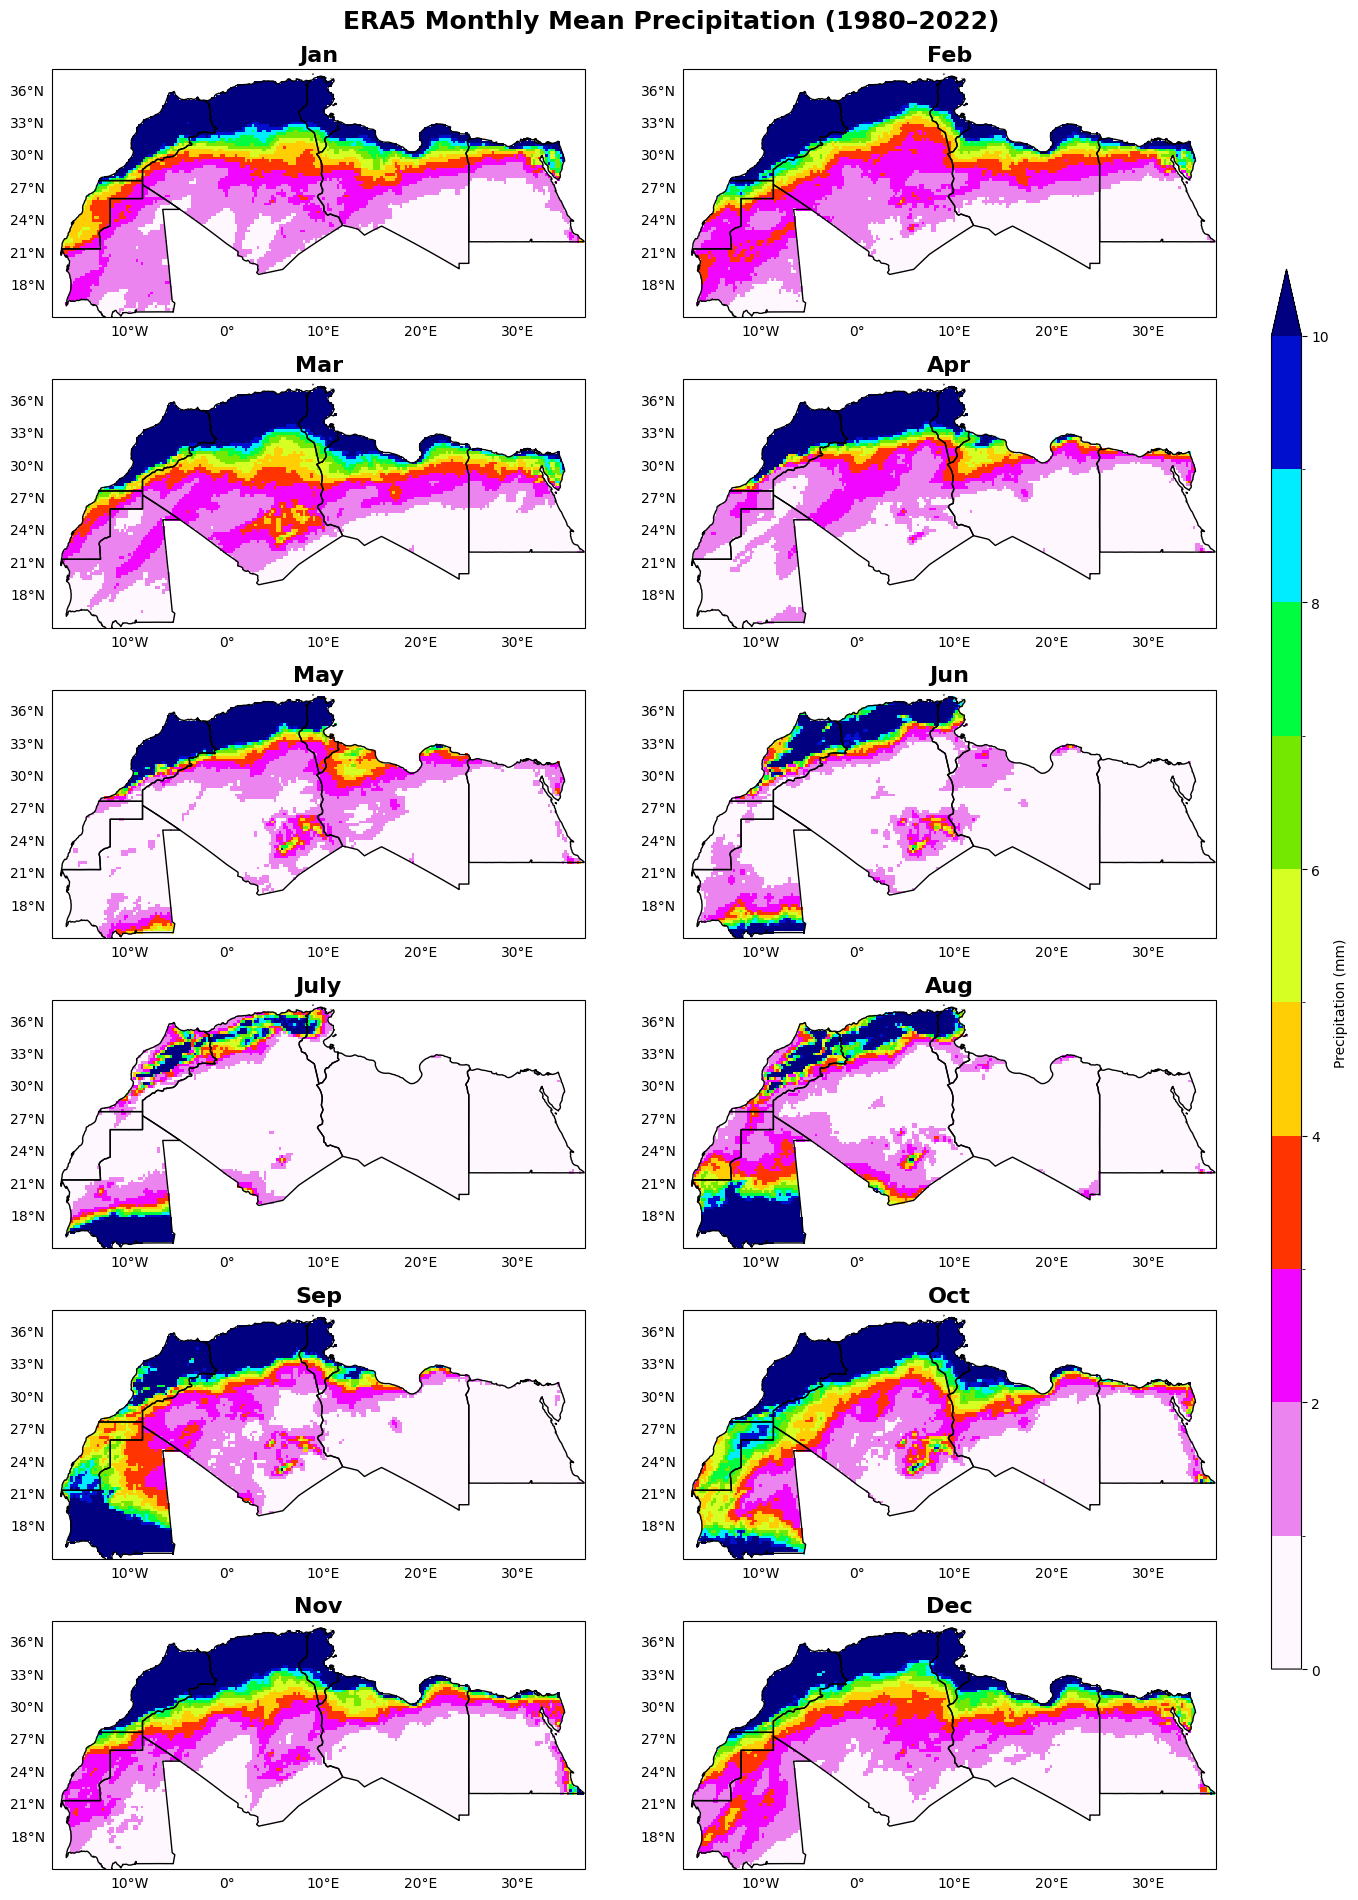

In [22]:
import matplotlib.ticker as mticker

######################### PLOT #######################################

pre_len = len(clim[param])
i = 0

fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(15, 20),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mon = ['Jan','Feb','Mar','Apr','May','Jun',
       'July','Aug','Sep','Oct','Nov','Dec']

levmin = 0
levi = 1
levmax = 10 + levi
clevs = np.arange(levmin, levmax, levi)

for ax in axes.flat:

    clim_m = clim[param][i]

    ax.set_extent([-18., 37., 15., 38.], crs=ccrs.PlateCarree())

    # Gridlines (labels only on left & bottom)
    gl = ax.gridlines(draw_labels=True)

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True

    # Remove grid lines
    gl.xlines = False
    gl.ylines = False

    # Custom tick locations
    gl.ylocator = mticker.FixedLocator([18, 21, 24, 27, 30, 33,36])
    gl.xlocator = mticker.MultipleLocator(10)

    dataplot = clim_m.plot.pcolormesh(
        ax=ax,
        cmap='gist_ncar_r',
        levels=clevs,
        add_colorbar=False
    )

    countries.plot(ax=ax, facecolor='none', edgecolor='k')

    ax.set_title(mon[i], fontweight="bold", fontsize=16)

    i += 1


plt.subplots_adjust(left=0.07, right=0.88, bottom=0.05, top=0.95,
                    wspace=0.08, hspace=0.25)

cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(dataplot, cax=cbar_ax, label="Precipitation (mm)")

fig.suptitle('ERA5 Monthly Mean Precipitation (1980–2022)',
             fontsize=18, fontweight="bold")

plt.show()

In [24]:


####################2           Anomaly########################################################
# Calculate monthly climatology and anomalies
clim_period = ds1.sel(valid_time=slice('1991-01-01', '2020-12-01'))
# monthly climatology by first applying the function groupby() to group the data array by month and then calculating the average for each monthly group.
clim_month = clim_period.groupby('valid_time.month').mean()

#Calculate monthly anomalies
anom = ds1.groupby('valid_time.month') - clim_month

anom_month =anom.groupby('valid_time.month').mean()

###########mask

poly=regionmask.Regions(countries.geometry)

mask = poly.mask(anom_month.longitude, anom_month.latitude)
clim_anom=anom_month.where(mask >= 0 )



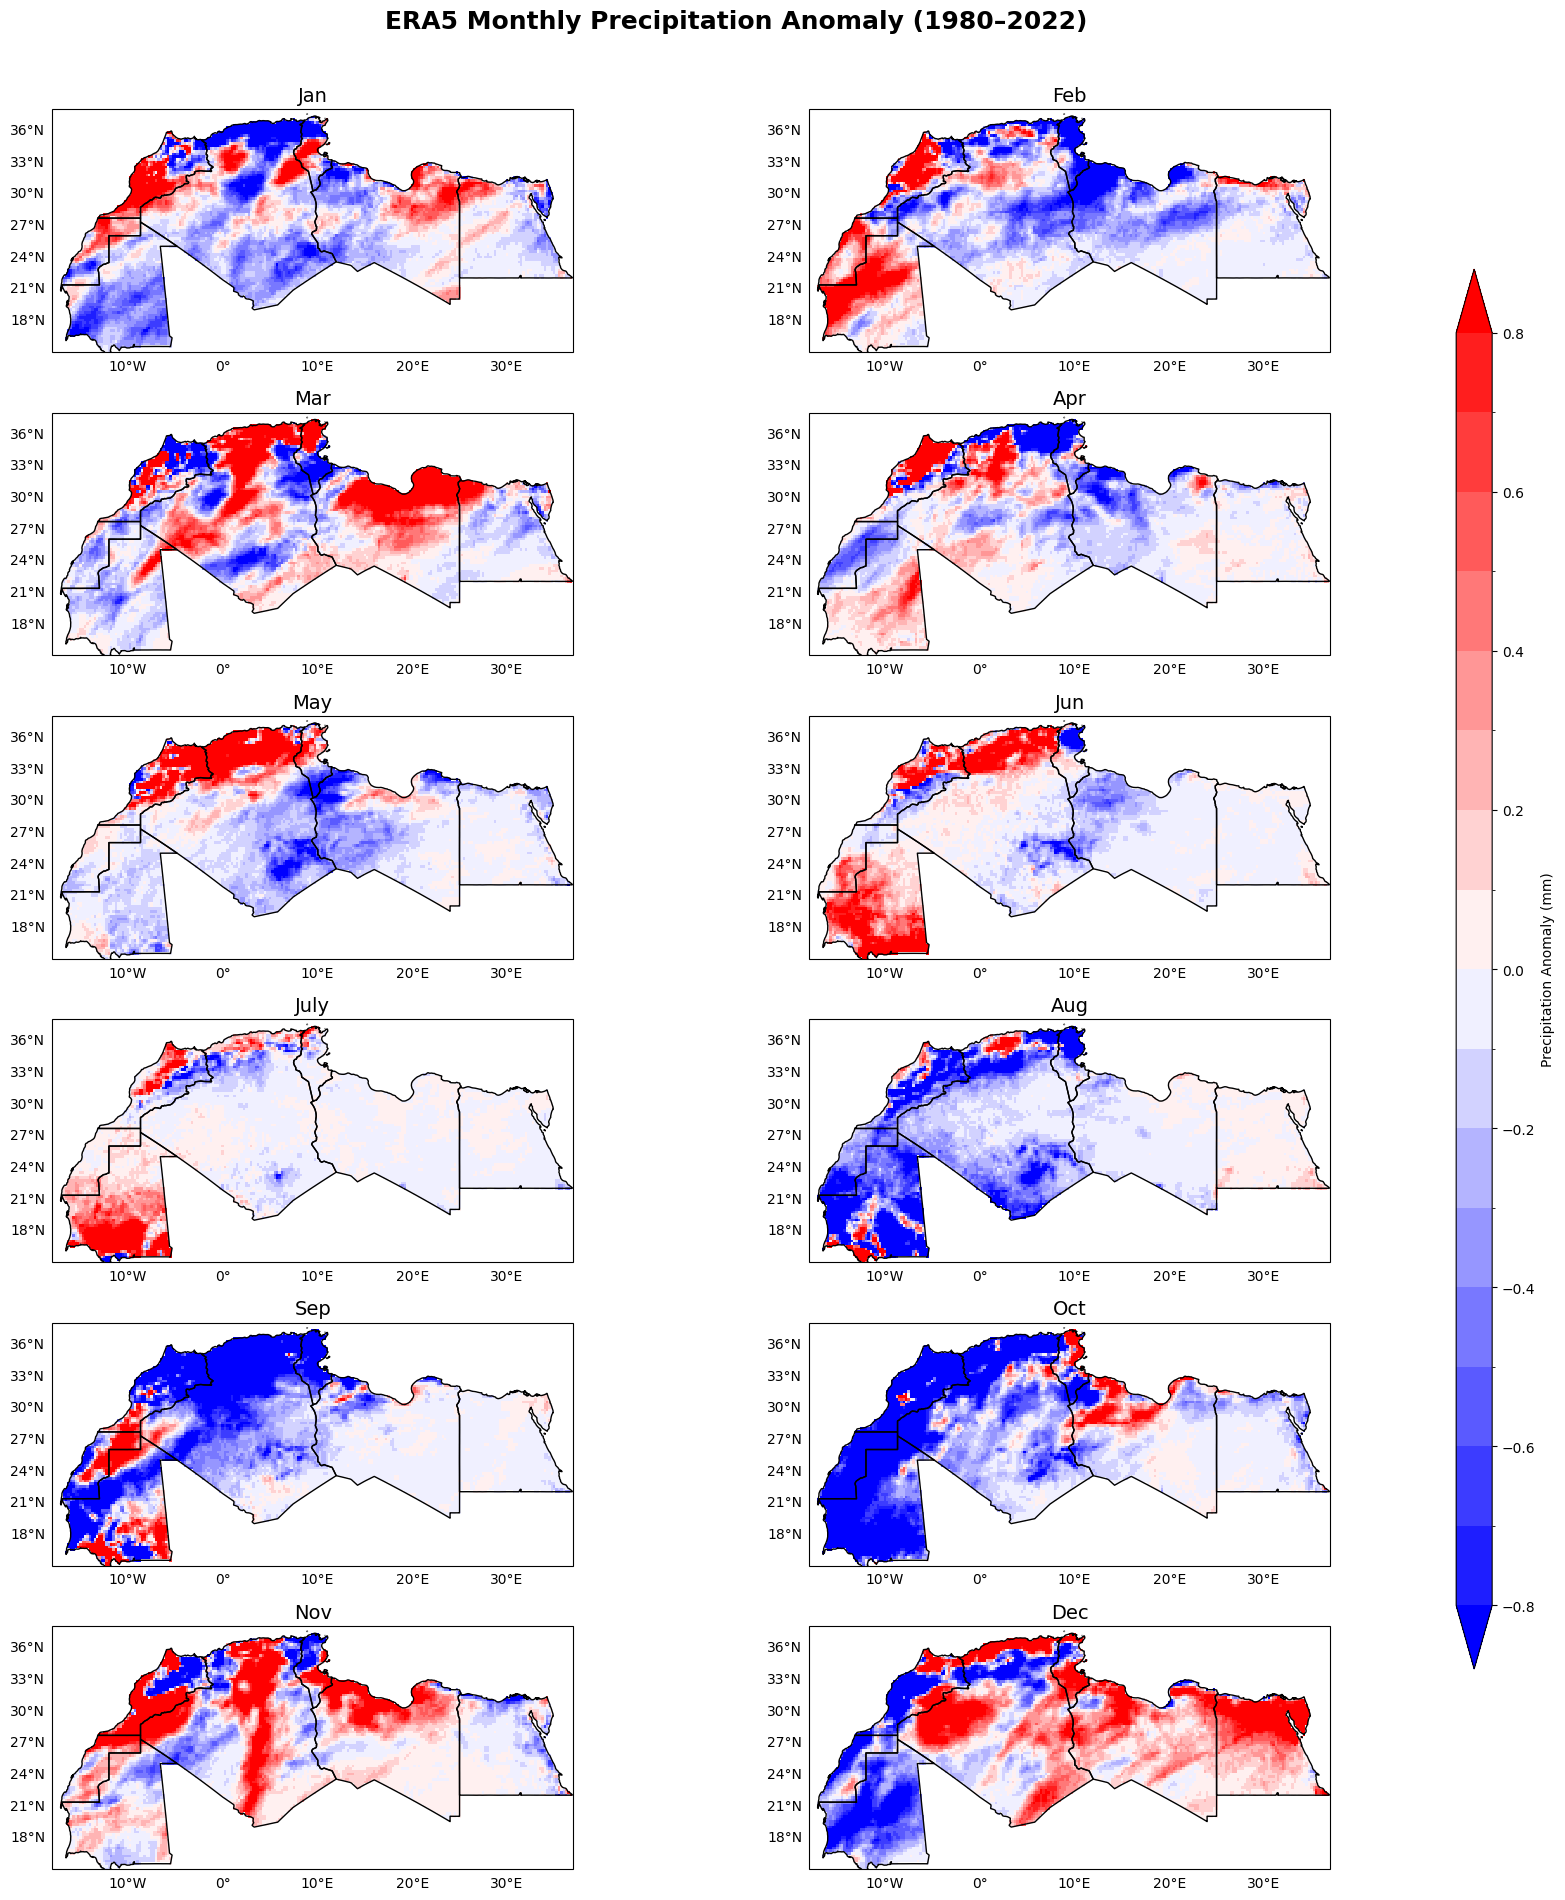

In [26]:
import matplotlib.ticker as mticker

######################### PLOT ANOMALY #######################################

pre_len = len(clim_anom[param])
i = 0

fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(18, 20),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mon = ['Jan','Feb','Mar','Apr','May','Jun',
       'July','Aug','Sep','Oct','Nov','Dec']

# Symmetric anomaly levels
levmin = -0.8
levi = 0.1
levmax = 0.8 + levi
clevs = np.arange(levmin, levmax, levi)

for ax in axes.flat:

    clim_m = clim_anom[param][i]

    ax.set_extent([-18., 37., 15., 38.], crs=ccrs.PlateCarree())

    # Gridlines (labels only left & bottom)
    gl = ax.gridlines(draw_labels=True)

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True

    # Remove grid lines
    gl.xlines = False
    gl.ylines = False

    # Custom tick spacing
    gl.ylocator = mticker.MultipleLocator(3)
    gl.xlocator = mticker.MultipleLocator(10)

    dataplot = clim_m.plot.pcolormesh(
        ax=ax,
        cmap='bwr',
        levels=clevs,
        add_colorbar=False
    )

    countries.plot(ax=ax, facecolor='none', edgecolor='k')

    ax.set_title(mon[i], fontsize=14)

    i += 1


# Adjust spacing BEFORE colorbar
plt.subplots_adjust(left=0.07, right=0.88, bottom=0.05, top=0.93,
                    wspace=0.08, hspace=0.25)

# Shared colorbar
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(dataplot, cax=cbar_ax, label="Precipitation Anomaly (mm)")

fig.suptitle('ERA5 Monthly Precipitation Anomaly (1980–2022)',
             fontsize=18, fontweight="bold")

plt.show()

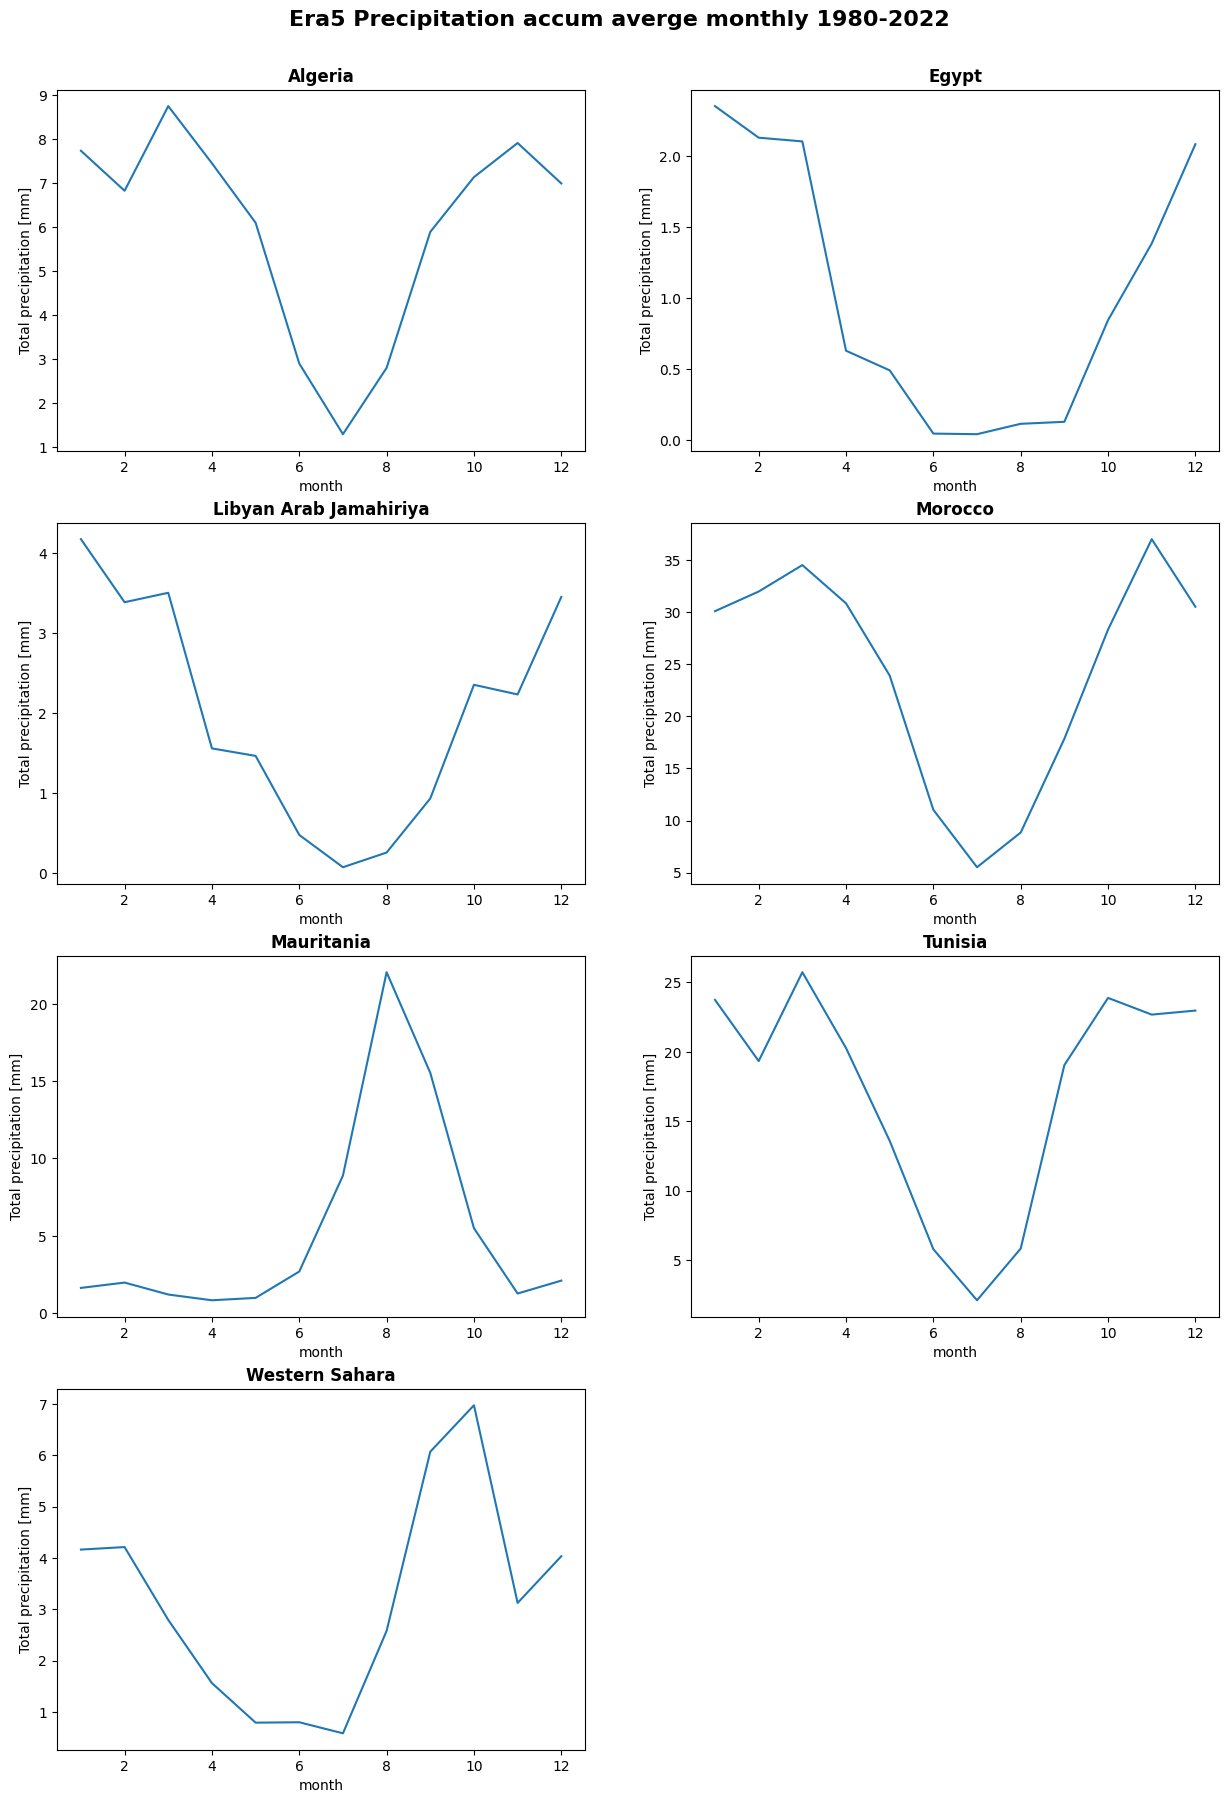

In [36]:
#..................................area average..................,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
########countries##########33
clim_month =ds1.groupby('valid_time.month').mean()

###########mask

poly=regionmask.Regions(countries.geometry)

mask = poly.mask(clim_month.longitude, clim_month.latitude)
clim=clim_month.where(mask >= 0 )

mask_mean=clim.groupby(mask).mean()

#########################plot#######################################33 cmap='bwr',sharex=True,sharey=True
i=0
fig, axes = plt.subplots(4, 2,figsize=(15,20))
mon=['Algeria','Egypt','Libyan Arab Jamahiriya','Morocco','Mauritania','Tunisia','Western Sahara']

for ax in axes.flat:
        if i != 7 :
            clim_m=mask_mean[param][i]
            dataplot = clim_m.plot(ax=ax)
            ax.set_title(mon[i],fontweight="bold")
            i=i+1
fig.delaxes(axes[3][1])  
plt.subplots_adjust(top=.94)
fig.suptitle('Era5 Precipitation accum averge monthly 1980-2022',fontsize=16,fontweight="bold")
#plt.savefig('/run/media/amal/My Passport/drought_projerct/result/avg_1.png')
plt.show()

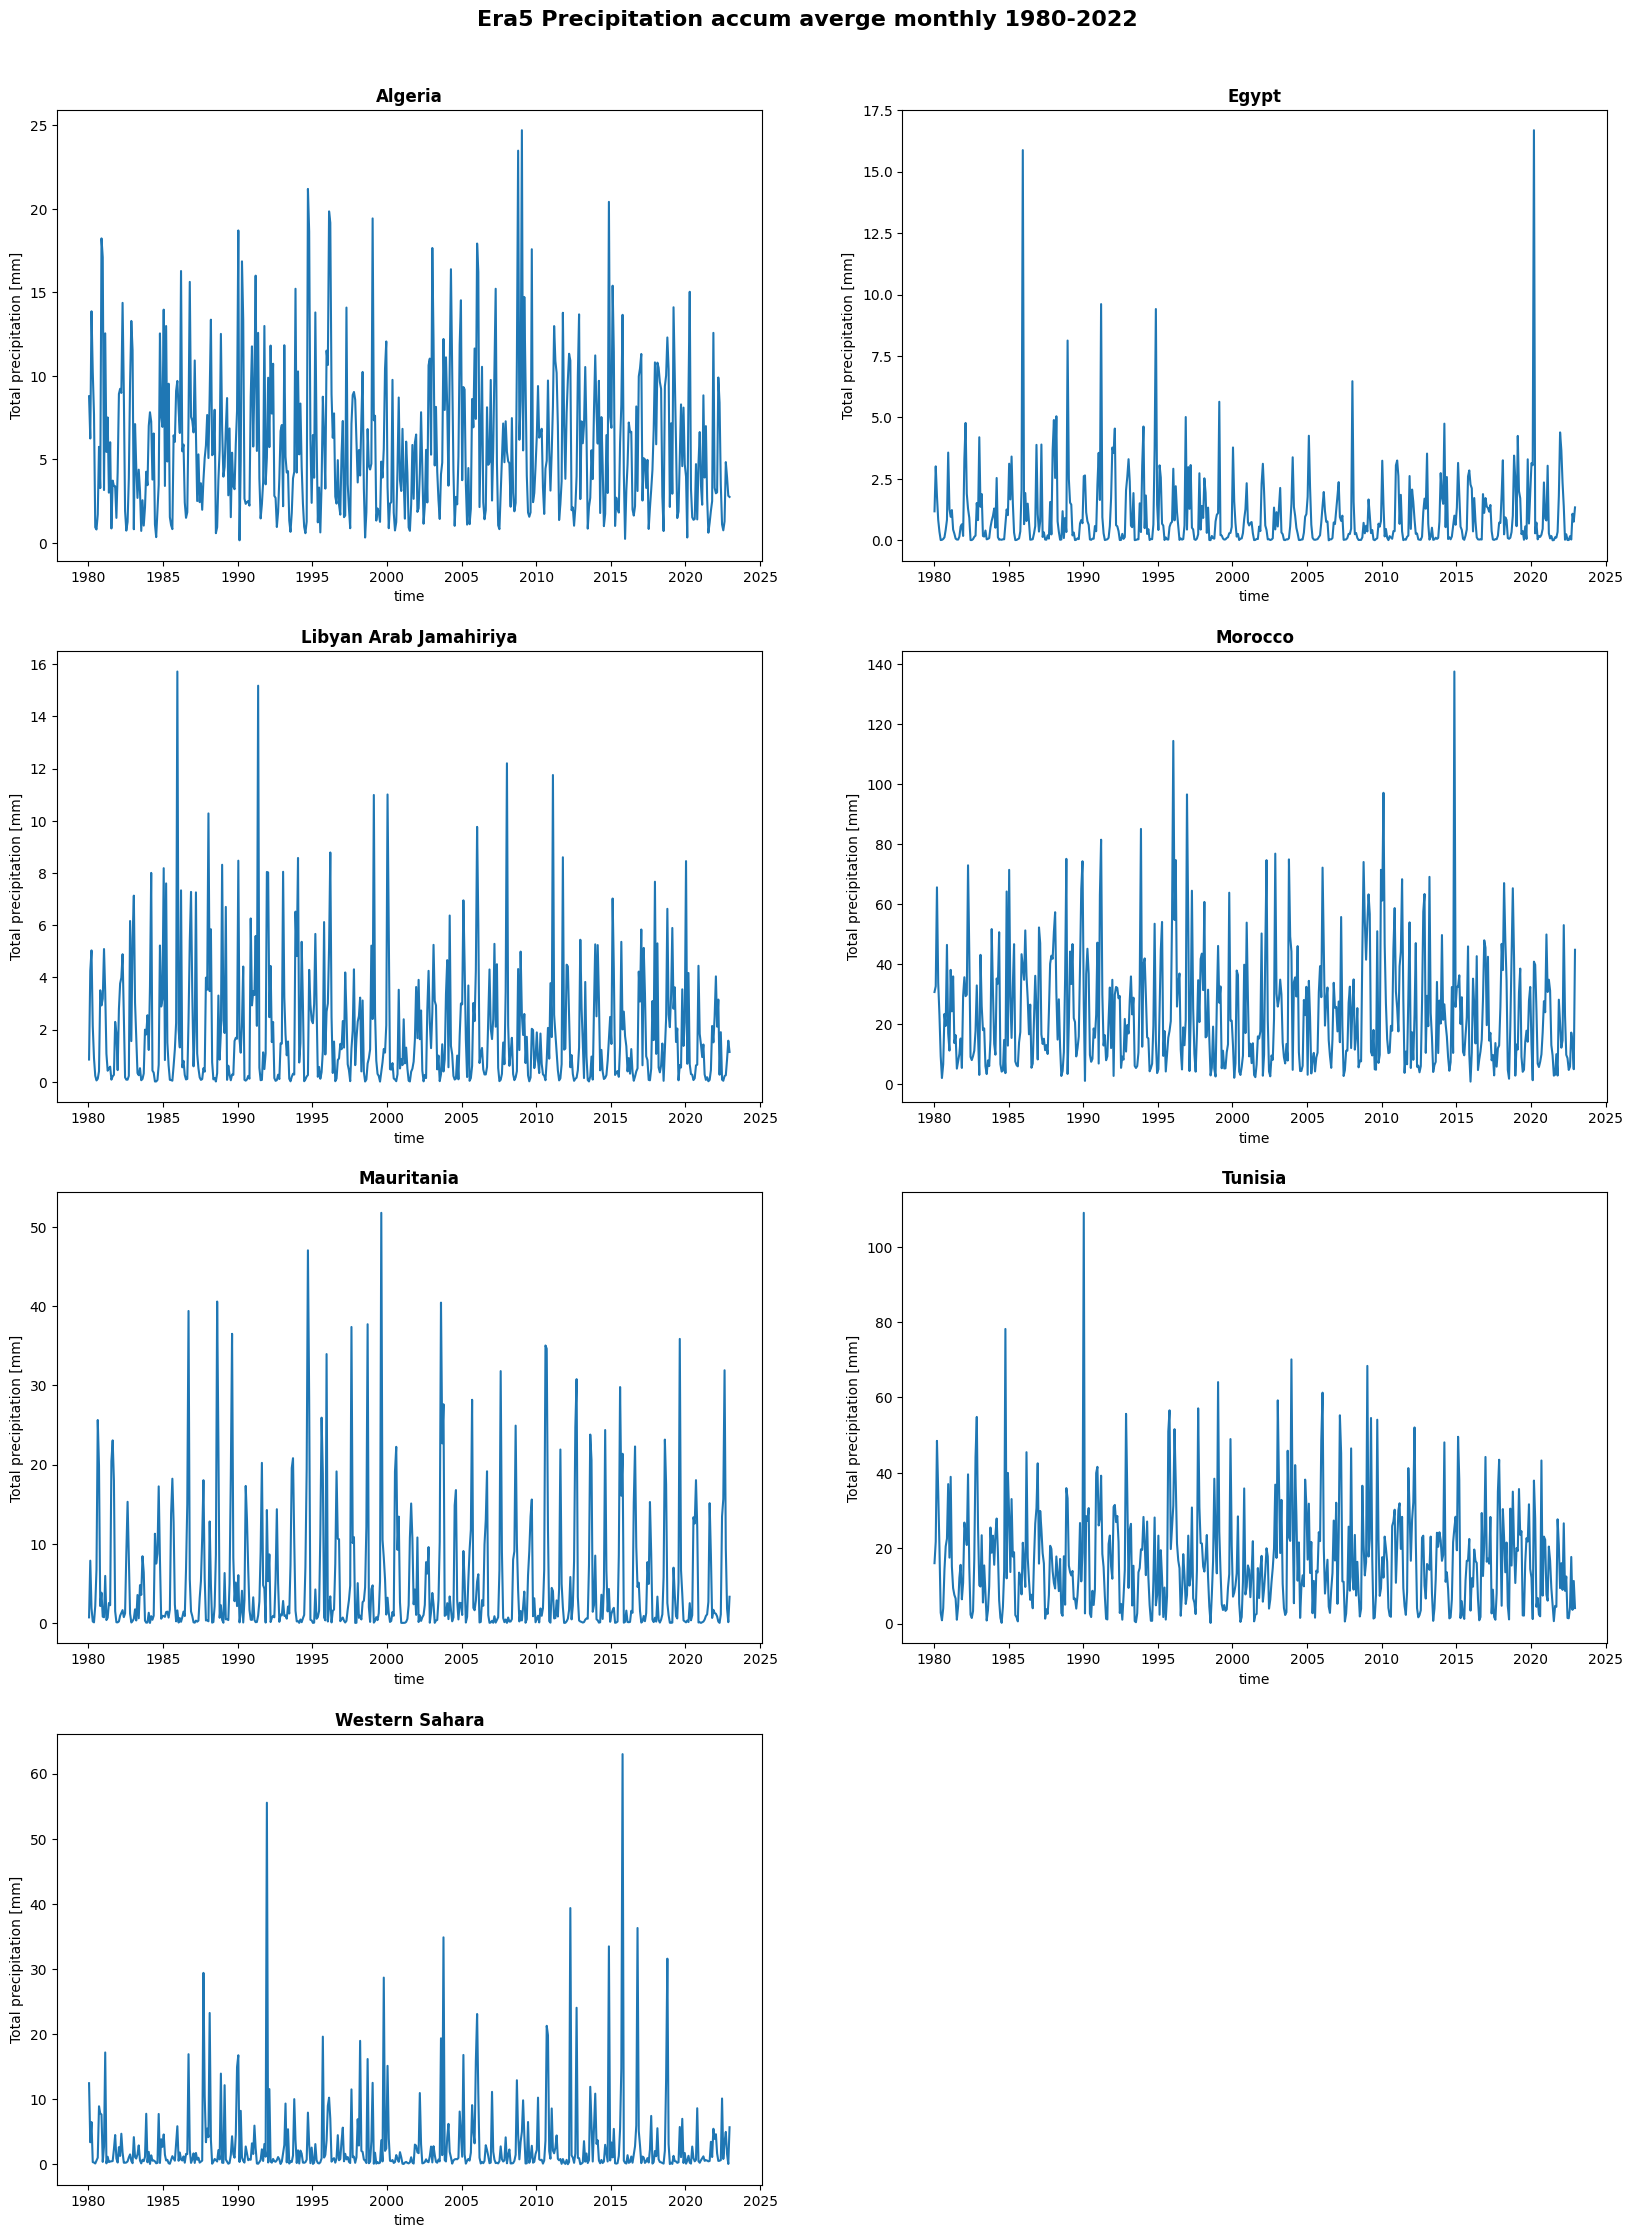

In [39]:


###########monthly average mask .....................................................

poly=regionmask.Regions(countries.geometry)

mask = poly.mask(ds1.longitude, ds1.latitude)
clim=ds1.where(mask >= 0 )


mask_mean=clim.groupby(mask).mean()
#mask_mean['tp'][7].plot()

#########################plot#######################################33 cmap='bwr',sharex=True,sharey=True
i=0
fig, axes = plt.subplots(4, 2,figsize=(20,25))
mon=['Algeria','Egypt','Libyan Arab Jamahiriya','Morocco','Mauritania','Tunisia','Western Sahara']

for ax in axes.flat:
        if i != 7 :
            clim_m=mask_mean[param][i]
            dataplot = clim_m.plot(ax=ax)
            ax.set_title(mon[i],fontweight="bold")
            i=i+1
fig.delaxes(axes[3][1])  
plt.subplots_adjust(top=.94)
fig.suptitle('Era5 Precipitation accum averge monthly 1980-2022',fontsize=16,fontweight="bold")
#plt.savefig('/run/media/amal/My Passport/drought_projerct/result/average_monthly_area.png')
plt.show()


In [29]:
seasonal = ds1.groupby("valid_time.season").mean('valid_time')
seasonal
###########mask

poly=regionmask.Regions(countries.geometry)

mask = poly.mask(seasonal.longitude, seasonal.latitude)
clim=seasonal.where(mask >= 0 )

/tmp/ipykernel_5220/262515473.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


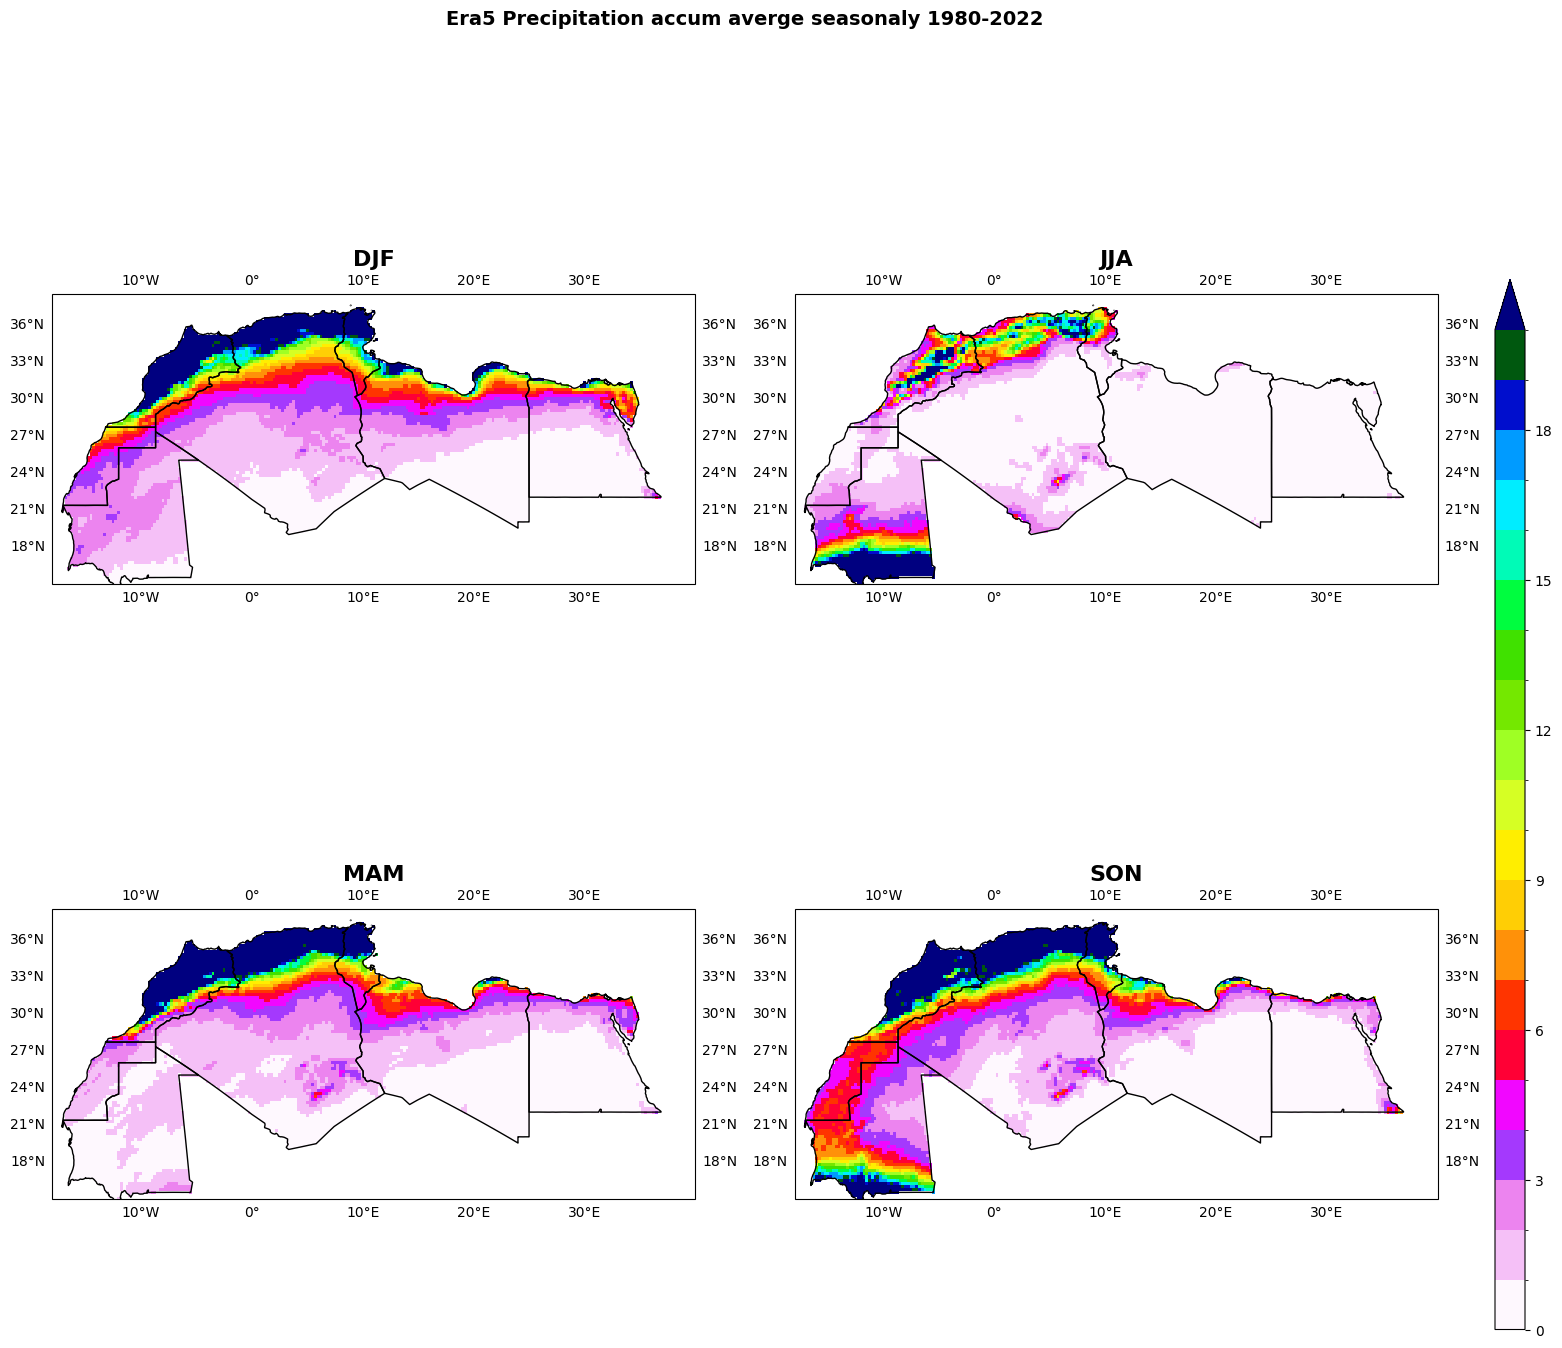

In [34]:

#########################plot#######################################33 cmap='bwr',sharex=True,sharey=True
pre_len=len(seasonal[param])
i=0
fig, axes = plt.subplots(nrows=2, ncols=2,figsize=(15,15), subplot_kw={'projection': ccrs.PlateCarree()})
mon=['DJF','JJA','MAM','SON']
cbar_ax = fig.add_axes([1, 0.1, 0.02, 0.7])
levmin=0
levi=1
levmax=20+levi
clevs=np.arange(levmin,levmax,levi)

for ax in axes.flat:
    ax.label_outer()
    clim_m=clim[param][i]
    ax.set_extent([-18., 40., 15., 35.])
    gl=ax.gridlines(draw_labels=True)
    gl.xlabels_top = False
    gl.ylabels_right = False
    gl.xlines = False
    gl.ylines = False
    dataplot = clim_m.plot.pcolormesh(ax=ax,cmap='gist_ncar_r',levels=clevs,add_colorbar=False)
    countries.plot(ax=ax, facecolor='none', edgecolor = 'k') # Plot the shapefile on the same ax, with black lines and no fill color.
    ax.set_title(mon[i],fontweight="bold",fontsize=16)
    i=i+1
   # ax.label_outer()

fig.suptitle('Era5 Precipitation accum averge seasonaly 1980-2022',fontsize=14,fontweight="bold")
#plt.subplots_adjust(left=0.1,right=0.9,bottom=0.2,top=1,wspace=0,hspace=1)

fig.tight_layout()
fig.colorbar(dataplot, cax=cbar_ax)   
#plt.savefig('/run/media/amal/My Passport/drought_projerct/result/africa_era5_pre_monthy_1980-2022_seasonal_2.png')
plt.show()



